# 📊 Tema 8: Visualización de Datos con Python (Parte I)

¡Bienvenido/a al arte de contar historias con datos!

Tener millones de registros limpios en un DataFrame está muy bien para la computadora, pero el cerebro humano entiende mejor las tendencias y patrones a través de imágenes. En este cuaderno exploraremos **Matplotlib**, la librería madre de la visualización en Python, que nos permite generar desde simples gráficos de líneas hasta complejos dashboards interactivos.

## 🚀 Contenido del Cuaderno

1. **Visualización con Matplotlib y Pyplot:** La anatomía de un gráfico.
2. **Gráficos de Series de Tiempo:** Mostrando evolución.
3. **Visualizaciones Estadísticas:** Histogramas, diagramas de caja y barras.
4. **Ejercicios Prácticos:** Análisis visual de los pasajeros del RMS Titanic.
5. **Nivel Pro:** Creación de un Dashboard (Subplots) y exportación de imágenes.
6. **Glosario Técnico y Conclusión.**

---
> **Instrucciones:** Ejecuta las celdas de código paso a paso. Asegúrate de tener instalada la librería usando `pip install matplotlib`.

## 1. La anatomía de Matplotlib y Pyplot



Matplotlib funciona bajo una jerarquía orientada a objetos:
1. **Figure (`fig`):** Es el lienzo en blanco completo. Puede contener uno o múltiples gráficos.
2. **Axes (`ax`):** Es el gráfico individual dentro del lienzo (con sus ejes X e Y, título, etc.).

Usamos el módulo `pyplot` (comúnmente importado como `plt`) porque nos proporciona comandos rápidos similares a los del software MATLAB para dibujar sobre estos ejes.

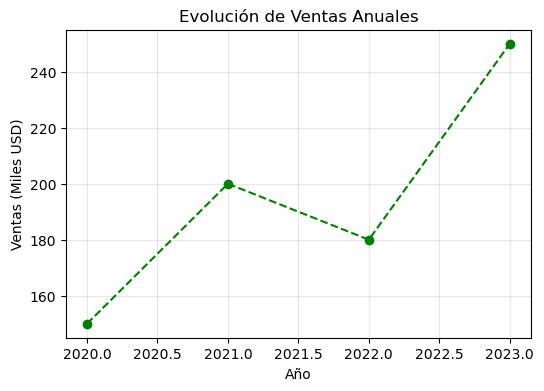

In [1]:
import matplotlib.pyplot as plt

# 💡 Ejemplo 1: Gráfico de Líneas (Series de tiempo / Evolución)
años = [2020, 2021, 2022, 2023]
ventas = [150, 200, 180, 250]

# plt.subplots() crea el Lienzo (fig) y el Gráfico (ax) al mismo tiempo
fig, ax = plt.subplots(figsize=(6, 4))

# Trazamos la línea
ax.plot(años, ventas, marker='o', color='green', linestyle='--')

# Configuramos el diseño
ax.set_title("Evolución de Ventas Anuales")
ax.set_xlabel("Año")
ax.set_ylabel("Ventas (Miles USD)")
ax.grid(True, alpha=0.3)

# Mostrar el gráfico en pantalla
plt.show()

## 2. Visualizaciones Cuantitativas y Estadísticas

Diferentes tipos de datos requieren diferentes tipos de gráficos:
* **Histograma (`ax.hist`):** Para ver la *distribución* de una variable continua (ej. ¿cuántas personas tienen entre 20 y 30 años?).
* **Diagrama de Caja (`boxplot`):** Para identificar valores atípicos (outliers) y ver dónde se concentra el 50% de los datos.
* **Gráfico de Barras (`ax.bar`):** Para comparar cantidades entre categorías distintas (ej. Ventas por país).

---
## 📝 Ejercicios Prácticos: El hundimiento del RMS Titanic

Para estos ejercicios, utilizaremos el famoso dataset del `titanic.csv` que documenta a los pasajeros del fatídico viaje de 1912.

### Ejercicio 1: Histograma de Frecuencias
**Objetivo:** A partir de la columna `Age` (Edad), obtenga el Histograma de frecuencias para ver la distribución de edades. Elimine valores faltantes y almacene el gráfico en la variable `hist`.

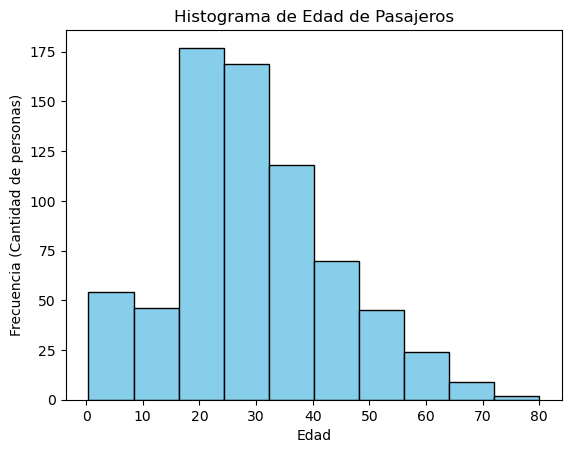

Frecuencias por intervalo: [ 54.  46. 177. 169. 118.  70.  45.  24.   9.   2.]


In [3]:
import pandas as pd

# URL cruda del dataset del Titanic para asegurar la ejecución en cualquier entorno
url_titanic = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url_titanic)

# --- Solución Ejercicio 1 ---
fig, ax = plt.subplots()

# Eliminar filas con valores faltantes en la columna 'Age'
df_edad = df.dropna(subset=['Age'])

# Crear el histograma (bins=10 divide los datos en 10 grupos de edad)
hist = ax.hist(df_edad['Age'], bins=10, edgecolor='black', color='skyblue')

# Establecer el título y las etiquetas
ax.set_title('Histograma de Edad de Pasajeros')
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia (Cantidad de personas)')

# Mostrar el gráfico
plt.show()

# Imprimir los datos del histograma para verificación (conteo de personas por intervalo)
print("Frecuencias por intervalo:", hist[0])

### Ejercicio 2: Diagrama de Caja (Boxplot)
**Objetivo:** Utilizando la misma columna `Age`, genere un diagrama de caja para visualizar la dispersión y los valores atípicos. Almacene el gráfico en la variable `box` como un diccionario.

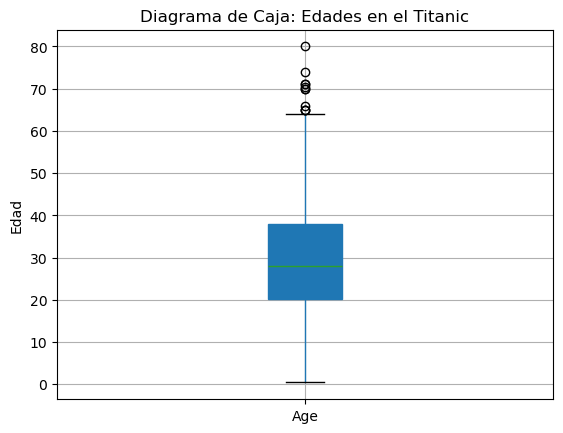

Diccionario del gráfico: {'whiskers': [<matplotlib.lines.Line2D object at 0x000001B659C860D0>, <matplotlib.lines.Line2D object at 0x000001B659C86210>], 'caps': [<matplotlib.lines.Line2D object at 0x000001B659C86350>, <matplotlib.lines.Line2D object at 0x000001B659C86490>], 'boxes': [<matplotlib.patches.PathPatch object at 0x000001B659476E40>], 'medians': [<matplotlib.lines.Line2D object at 0x000001B659C865D0>], 'fliers': [<matplotlib.lines.Line2D object at 0x000001B659C86710>], 'means': []}


In [4]:
# --- Solución Ejercicio 2 ---
fig, ax = plt.subplots()

# Crear el diagrama de caja para la columna 'Age'
# return_type='dict' nos permite guardar las partes del gráfico en un diccionario
box = df_edad.boxplot(column='Age', ax=ax, return_type='dict', patch_artist=True)

ax.set_title('Diagrama de Caja: Edades en el Titanic')
ax.set_ylabel('Edad')

# Mostrar el gráfico
plt.show()

# Imprimir el diccionario que contiene información sobre las líneas del diagrama
print("Diccionario del gráfico:", box)

### Ejercicio 3: Gráfico de Barras por Clase
**Objetivo:** Crear un gráfico que muestre el número de pasajeros de cada clase (variable `Pclass`). Almacenar el resultado en la variable `bar`.

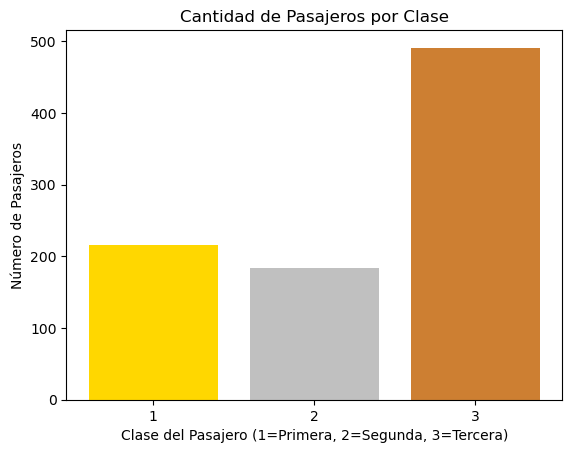

Tipo de variable 'bar': <class 'matplotlib.container.BarContainer'>


In [5]:
# --- Solución Ejercicio 3 ---
# Contar el número de pasajeros por clase y ordenarlos por índice (1ra, 2da, 3ra)
df_clase = df.dropna(subset=['Pclass'])
pclass_counts = df_clase['Pclass'].value_counts().sort_index()

# Crear el gráfico de barras
fig, ax = plt.subplots()
bar = ax.bar(pclass_counts.index, pclass_counts.values, color=['gold', 'silver', '#cd7f32'])

# Establecer etiquetas y título
ax.set_xlabel('Clase del Pasajero (1=Primera, 2=Segunda, 3=Tercera)')
ax.set_ylabel('Número de Pasajeros')
ax.set_title('Cantidad de Pasajeros por Clase')

# Ajustar los "ticks" (marcas) del eje X para que solo muestre números enteros
ax.set_xticks([1, 2, 3])

# Mostrar el gráfico
plt.show()

# Imprimir el tipo de la variable bar para confirmar que es un contenedor de barras
print("Tipo de variable 'bar':", type(bar))

## 🔍 Explicación de los Algoritmos e Impresiones

Al final de cada ejercicio, solicitamos imprimir las variables que almacenan los gráficos. ¿Por qué hicimos esto?
1. **`hist[0]`**: La función `.hist()` devuelve una tupla. El primer elemento (`[0]`) es un arreglo numérico con la **frecuencia real** (cantidad de personas) que cayó en cada uno de los 10 intervalos (bins).
2. **`return_type='dict'`**: El diagrama de caja está compuesto por bigotes (whiskers), cajas (boxes) y valores atípicos (fliers). Al devolverlo como diccionario, podríamos acceder al código de cada una de estas partes para cambiarles el color de forma individual.
3. **`BarContainer`**: La función `.bar()` devuelve un objeto especial que actúa como una lista de rectángulos. Esto confirma que el gráfico se generó y guardó exitosamente en la memoria.

## 🚀 Nivel Pro: Dashboards y Exportación de Gráficos

Generar gráficos uno por uno está bien para análisis exploratorio. Pero si tienes que presentar un informe a tu jefe, lo ideal es crear un **Dashboard** (un panel de control) que agrupe toda la información en una sola imagen de alta calidad, y luego exportar esa imagen automáticamente.

Aquí aplicaremos el concepto de **Subplots** y la instrucción de exportación (`plt.savefig`).

✅ ¡Dashboard generado y guardado exitosamente como 'dashboard_titanic.png'!


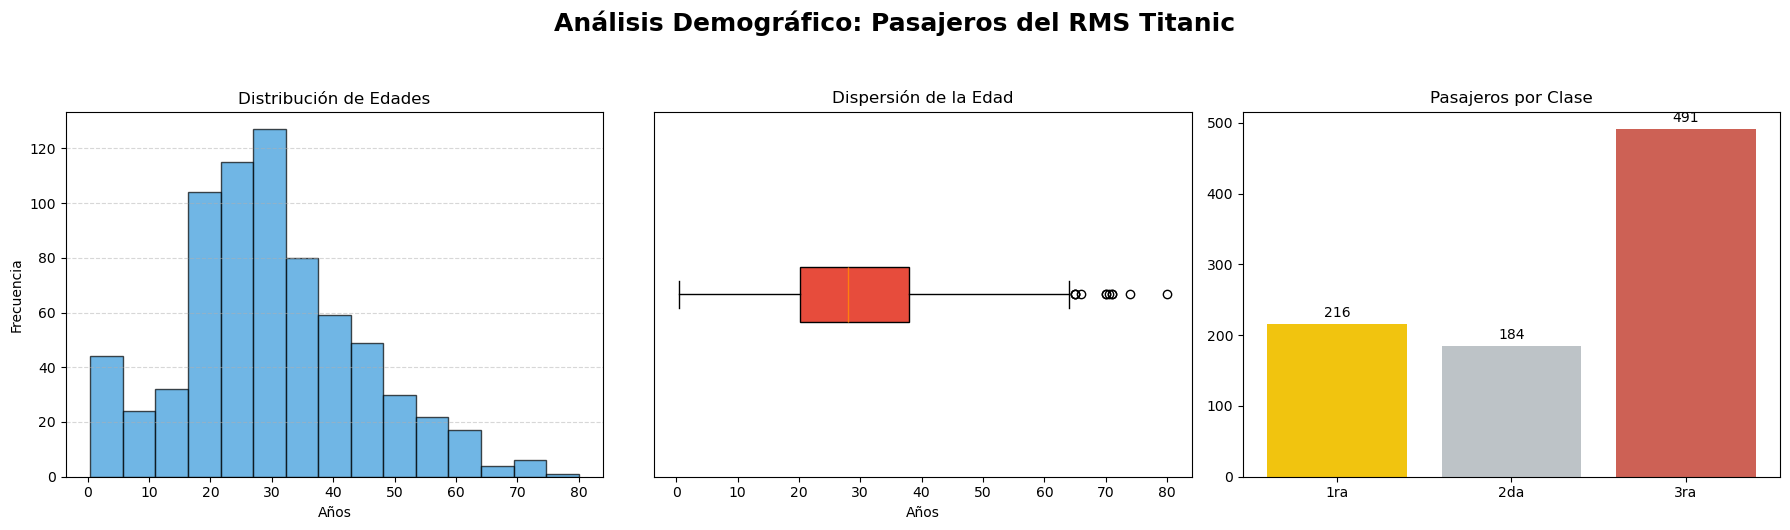

In [6]:
def generar_dashboard_titanic(url: str):
    """
    Descarga el dataset, procesa los datos y genera un Dashboard con 3 gráficos
    (Subplots) guardando el resultado en un archivo PNG.
    """
    df_data = pd.read_csv(url)
    
    # Preparamos los datos
    edades = df_data['Age'].dropna()
    clases = df_data['Pclass'].value_counts().sort_index()
    
    # 1. Creamos el lienzo (fig) especificando que tendrá 1 FILA y 3 COLUMNAS
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
    fig.suptitle('Análisis Demográfico: Pasajeros del RMS Titanic', fontsize=18, fontweight='bold', y=1.05)
    
    # --- Gráfico 1: Histograma (ax[0]) ---
    axes[0].hist(edades, bins=15, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribución de Edades')
    axes[0].set_xlabel('Años')
    axes[0].set_ylabel('Frecuencia')
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    
    # --- Gráfico 2: Diagrama de Caja (ax[1]) ---
    axes[1].boxplot(edades, vert=False, patch_artist=True, boxprops=dict(facecolor='#e74c3c'))
    axes[1].set_title('Dispersión de la Edad')
    axes[1].set_xlabel('Años')
    axes[1].set_yticks([]) # Ocultamos el texto del eje Y porque no aporta
    
    # --- Gráfico 3: Barras (ax[2]) ---
    barras = axes[2].bar(clases.index, clases.values, color=['#f1c40f', '#bdc3c7', '#cd6155'])
    axes[2].set_title('Pasajeros por Clase')
    axes[2].set_xticks([1, 2, 3])
    axes[2].set_xticklabels(['1ra', '2da', '3ra'])
    
    # Añadimos el número exacto encima de cada barra
    axes[2].bar_label(barras, padding=3)

    # 2. Ajustamos el diseño para que no se superpongan los textos
    plt.tight_layout()
    
    # 3. COMPARTIR VISUALIZACIÓN: Exportamos a imagen de alta resolución
    nombre_archivo = 'dashboard_titanic.png'
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    print(f"✅ ¡Dashboard generado y guardado exitosamente como '{nombre_archivo}'!")
    
    # 4. Mostramos en pantalla
    plt.show()

# Ejecutar la función profesional
if __name__ == "__main__":
    generar_dashboard_titanic(url_titanic)

## 🔍 Explicación de la Versión Profesional

1. **La técnica `subplots(1, 3)`:** Le indica a Matplotlib que genere una grilla con 1 fila y 3 espacios. La variable `axes` se convierte en una lista, por lo que podemos acceder al primer espacio con `axes[0]`, al segundo con `axes[1]` y así sucesivamente.
2. **Método `bar_label()`:** Un excelente truco analítico. Escribe automáticamente el valor numérico exacto encima de cada barra, facilitando la lectura para los tomadores de decisiones.
3. **Exportación con `savefig()`:** Esta es la respuesta al subtema de "Compartir visualizaciones". En lugar de tomar una captura de pantalla manual, el código guarda automáticamente la figura como un `.png` con alta resolución (`dpi=300`), lista para ser adjuntada en un correo o presentación.

# 🎉 Conclusión del Cuaderno: Contando historias con datos

¡Excelente trabajo! Has dado un paso gigante en tu formación. 

Saber realizar matemáticas avanzadas con Pandas y NumPy es crucial, pero la habilidad de **comunicar esos resultados** a personas sin perfil técnico es lo que diferencia a un programador de un verdadero Científico de Datos. 

### 🧠 ¿Qué nos llevamos de este módulo?
* Entendimos la **anatomía jerárquica** de Matplotlib (Figuras y Ejes).
* Comprendimos qué gráfico usar según la necesidad: **Histogramas y Boxplots** para distribuciones estadísticas, y **Gráficos de Barras** para el conteo de categorías puras.
* Descubrimos que las funciones de graficación devuelven objetos y diccionarios con información detallada detrás de bambalinas.
* Logramos estructurar visualizaciones de nivel corporativo combinando múltiples gráficos en un solo **Dashboard** y exportándolos en alta calidad para ser compartidos.

## 📚 Glosario de Visualización de Datos



Para finalizar, repasemos formalmente la terminología estadística y de visualización utilizada durante este tema:

* **Diagrama de caja y bigotes (Boxplot):** Un tipo de gráfico que muestra la distribución de un conjunto de datos a través de sus cuartiles, destacando la dispersión, la mediana y revelando claramente los valores atípicos (outliers).
* **Diagrama de dispersión (Scatter Plot):** Un gráfico que utiliza coordenadas cartesianas para mostrar valores de dos variables numéricas para un conjunto de datos, sumamente útil para identificar relaciones o correlaciones.
* **Gráfico de barras apiladas:** Una variación del gráfico de barras que permite representar diferentes subcategorías dentro de una misma categoría principal, apilando las barras una sobre otra para ver la composición total.
* **Gráfico de líneas:** Un tipo de gráfico que conecta una serie de puntos de datos individuales con líneas rectas, utilizado clásicamente para mostrar tendencias a lo largo del tiempo (series temporales).
* **Histograma:** Un gráfico que representa la distribución general de un conjunto de datos numéricos continuos mediante barras que muestran la frecuencia con la que aparecen datos en intervalos (bins) específicos.
* **Interpolación:** Un método matemático para estimar valores desconocidos dentro del rango de un conjunto de datos conocido, muy utilizado para rellenar datos faltantes en series de tiempo antes de graficarlas.
* **Matplotlib:** Una librería fundamental de Python utilizada para crear gráficos bidimensionales estáticos, animados e interactivos, esencial para la visualización de datos en ciencia y estadística.
* **Pyplot:** Un submódulo específico de Matplotlib (comúnmente importado como `plt`) que proporciona una interfaz de comandos rápida y sencilla, similar a MATLAB, para la creación de gráficos paso a paso.
* **Subplot:** Una técnica o comando que permite organizar y acomodar múltiples gráficos (Axes) dentro de una sola figura o ventana (Figure), facilitando la comparación visual de diferentes conjuntos de datos en un "dashboard".